## Import Libraries

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## Load dataset

In [52]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## Initial Data Exploration

In [53]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [54]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [55]:
print("Unique Seasons:", df['Season'].unique())
print("Unique States:", df['State'].nunique())
print("Unique Crops:", df['Crop'].unique())
print("Irrigation Methods:", df['Irrigation_Method'].unique())
print("\nRecords per season:")
print(df['Season'].value_counts())


Unique Seasons: <StringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str
Unique States: 8
Unique Crops: <StringArray>
[    'Wheat',     'Maize',    'Pulses',      'Rice',    'Cotton',    'Chilli',
 'Groundnut', 'Sugarcane']
Length: 8, dtype: str
Irrigation Methods: <StringArray>
['Drip', 'Flood', 'Rainfed', 'Sprinkler']
Length: 4, dtype: str

Records per season:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


## Data Cleaning

In [56]:
# Check missing values
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing values per column:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


In [57]:
# Check for duplicate records
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Farm_IDs:", df['Farm_ID'].duplicated().sum())


Duplicate rows: 0
Duplicate Farm_IDs: 0


In [58]:
# Handle missing values: Rainfall_mm, Soil_Moisture_pct, Yield_Tonnes_Ha
# Use season-wise median imputation since these values vary by season
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


In [59]:
# Recompute Production_Tonnes consistency check (Yield * Area) - sanity check only, not overwritten
df['Yield_Check'] = df['Yield_Tonnes_Ha'] * df['Farm_Area_Hectares']
print(df[['Yield_Tonnes_Ha','Farm_Area_Hectares','Production_Tonnes','Yield_Check']].head())
df.drop(columns=['Yield_Check'], inplace=True)


   Yield_Tonnes_Ha  Farm_Area_Hectares  Production_Tonnes  Yield_Check
0             2.46                0.53               1.30       1.3038
1             0.30                6.53               1.96       1.9590
2             0.52                4.86               2.53       2.5272
3             1.84                4.50               8.28       8.2800
4             2.21                4.21               9.30       9.3041


## Seasonal Comparison of Key Performance Metrics

In [60]:

season_summary = df.groupby('Season')[['Yield_Tonnes_Ha','Production_Tonnes',
                                        'Total_Cost_INR','Revenue_INR','Profit_INR',
                                        'Water_Used_m3','Water_Efficiency_t_per_1000m3']].mean().round(2)
season_order = ['Kharif','Rabi','Zaid']
season_summary = season_summary.reindex(season_order)
season_summary


,Yield_Tonnes_Ha,Production_Tonnes,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,,,,
Kharif,5.63,46.31,531804.41,710719.06,178914.65,6102.20,5.89
Rabi,5.04,41.49,513836.58,601526.05,87689.47,5846.99,5.19
Zaid,4.64,38.89,543976.73,519171.90,-24804.82,6419.89,4.41


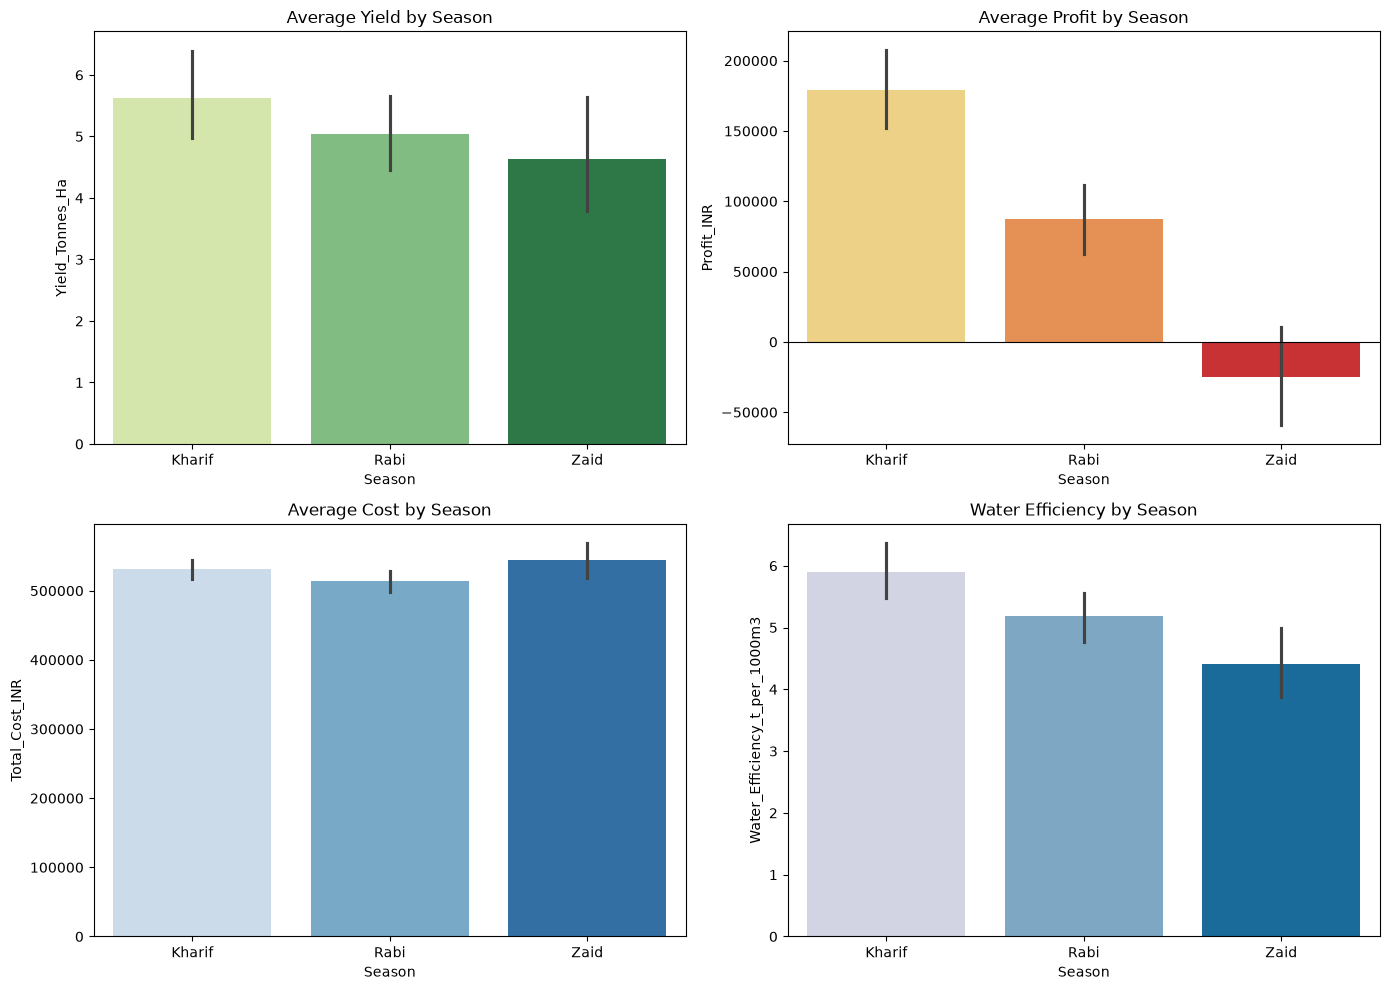

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=season_order, 
            hue='Season', legend=False, ax=axes[0,0], palette='YlGn')
axes[0,0].set_title('Average Yield by Season')

sns.barplot(data=df, x='Season', y='Profit_INR', order=season_order, 
            hue='Season', legend=False, ax=axes[0,1], palette='YlOrRd')
axes[0,1].axhline(0, color='black', linewidth=0.8)
axes[0,1].set_title('Average Profit by Season')

sns.barplot(data=df, x='Season', y='Total_Cost_INR', order=season_order, 
            hue='Season', legend=False, ax=axes[1,0], palette='Blues')
axes[1,0].set_title('Average Cost by Season')

sns.barplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', order=season_order, 
            hue='Season', legend=False, ax=axes[1,1], palette='PuBu')
axes[1,1].set_title('Water Efficiency by Season')

plt.tight_layout()
plt.savefig('season_kpi_overview.png', dpi=120)
plt.show()

## Profitability Analysis

In [62]:

loss_making = df[df['Profit_INR'] < 0]
print(f"Total loss-making farms: {len(loss_making)} out of {len(df)} ({len(loss_making)/len(df)*100:.1f}%)")
print()
print("Loss-making farms by season:")
print(loss_making['Season'].value_counts())
print()
print("Share of farms making a loss, by season:")
print((df.groupby('Season').apply(lambda x: (x['Profit_INR']<0).mean()*100)).round(1))


Total loss-making farms: 1966 out of 4000 (49.1%)

Loss-making farms by season:
Season
Rabi      832
Kharif    751
Zaid      383
Name: count, dtype: int64

Share of farms making a loss, by season:
Season
Kharif    42.2
Rabi      51.1
Zaid      64.5
dtype: float64


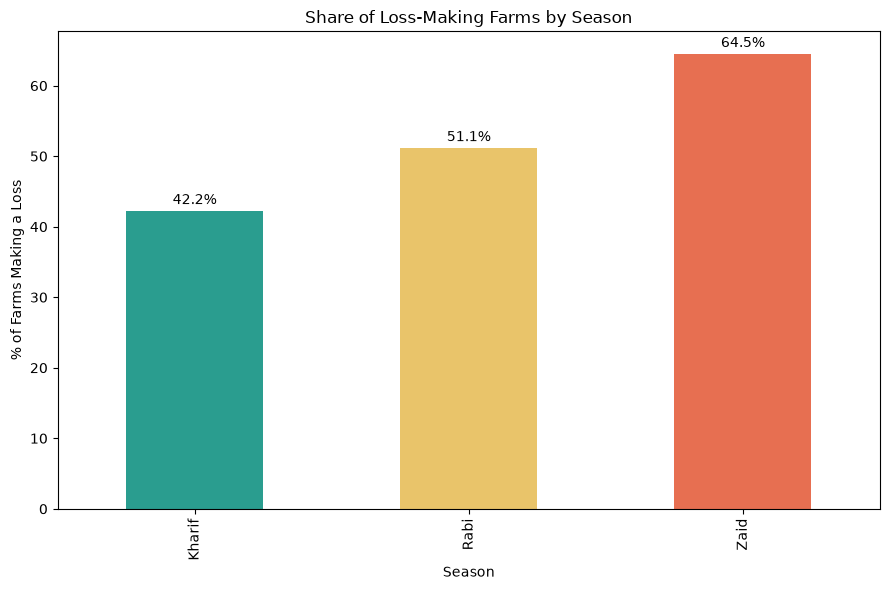

In [63]:
fig, ax = plt.subplots(figsize=(9,6))
loss_pct = df.groupby('Season').apply(lambda x: (x['Profit_INR']<0).mean()*100).reindex(season_order)
loss_pct.plot(kind='bar', color=['#2a9d8f','#e9c46a','#e76f51'], ax=ax)
ax.set_ylabel('% of Farms Making a Loss')
ax.set_title('Share of Loss-Making Farms by Season')
for i, v in enumerate(loss_pct):
    ax.text(i, v+1, f"{v:.1f}%", ha='center')
plt.tight_layout()
plt.savefig('loss_share_by_season.png', dpi=120)
plt.show()


## Environmental Conditions Across Seasons

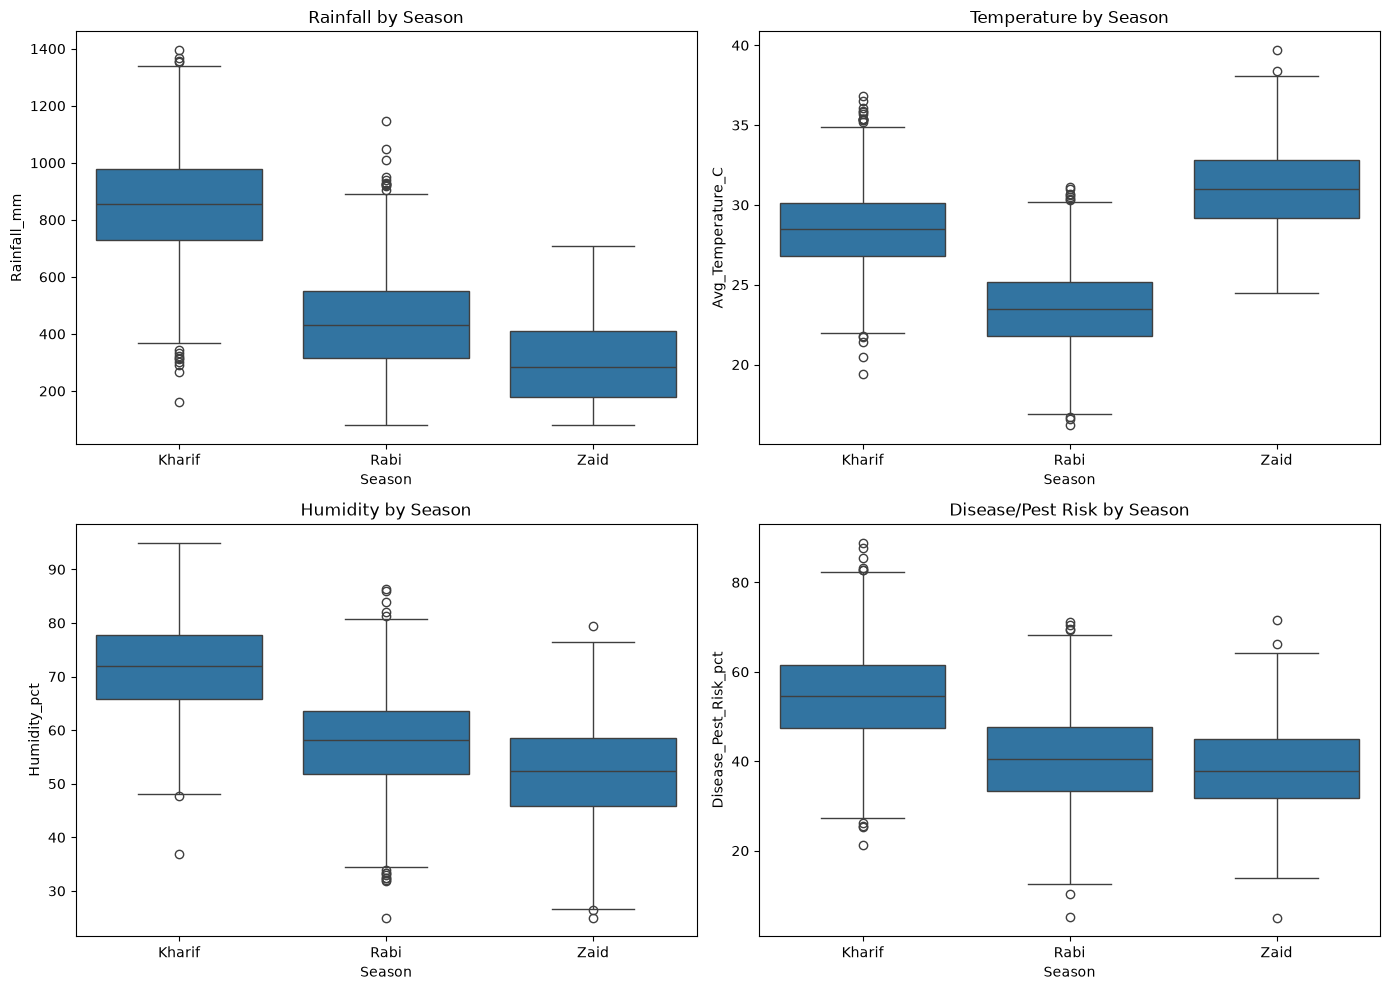

In [64]:

fig, axes = plt.subplots(2, 2, figsize=(14,10))

sns.boxplot(data=df, x='Season', y='Rainfall_mm', order=season_order, ax=axes[0,0])
axes[0,0].set_title('Rainfall by Season')

sns.boxplot(data=df, x='Season', y='Avg_Temperature_C', order=season_order, ax=axes[0,1])
axes[0,1].set_title('Temperature by Season')

sns.boxplot(data=df, x='Season', y='Humidity_pct', order=season_order, ax=axes[1,0])
axes[1,0].set_title('Humidity by Season')

sns.boxplot(data=df, x='Season', y='Disease_Pest_Risk_pct', order=season_order, ax=axes[1,1])
axes[1,1].set_title('Disease/Pest Risk by Season')

plt.tight_layout()
plt.savefig('environment_by_season.png', dpi=120)
plt.show()


## Resource Usage Across Seasons

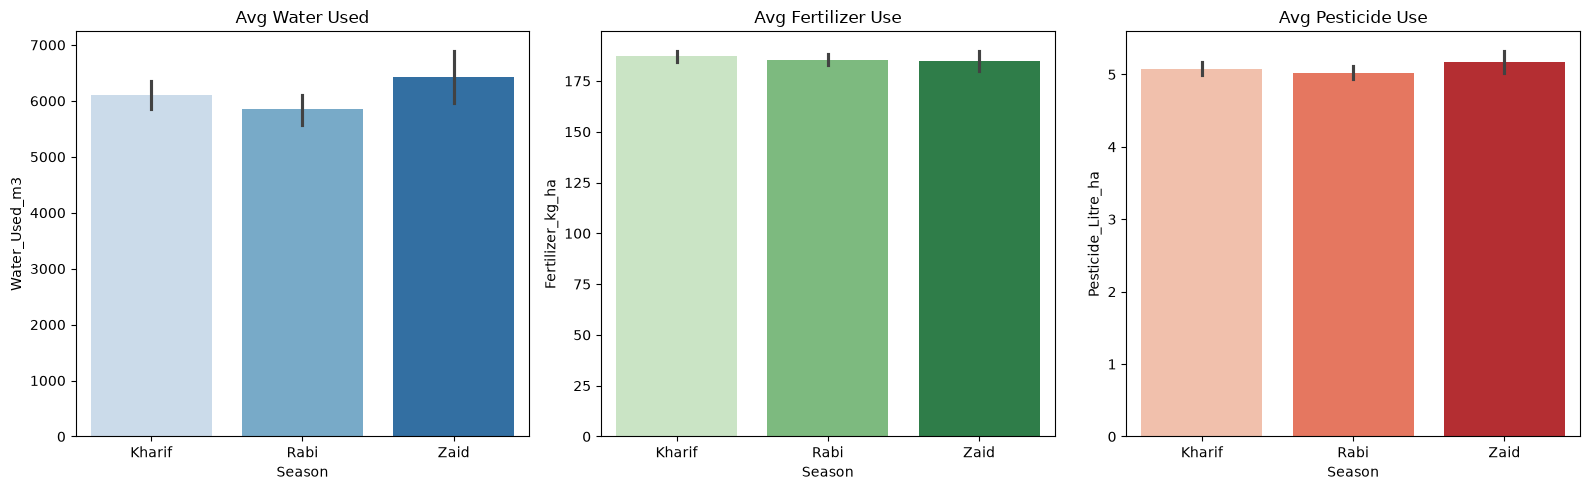

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))

sns.barplot(data=df, x='Season', y='Water_Used_m3', order=season_order, 
            hue='Season', legend=False, ax=axes[0], palette='Blues')
axes[0].set_title('Avg Water Used')

sns.barplot(data=df, x='Season', y='Fertilizer_kg_ha', order=season_order, 
            hue='Season', legend=False, ax=axes[1], palette='Greens')
axes[1].set_title('Avg Fertilizer Use')

sns.barplot(data=df, x='Season', y='Pesticide_Litre_ha', order=season_order, 
            hue='Season', legend=False, ax=axes[2], palette='Reds')
axes[2].set_title('Avg Pesticide Use')

plt.tight_layout()
plt.savefig('resource_usage_by_season.png', dpi=120)
plt.show()

In [66]:
# Irrigation method distribution by season
irrigation_season = pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index') * 100
irrigation_season = irrigation_season.reindex(season_order)
irrigation_season.round(1)


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.8,33.2,26.0,18.0
Rabi,22.7,32.3,26.9,18.0
Zaid,23.6,32.7,23.6,20.2


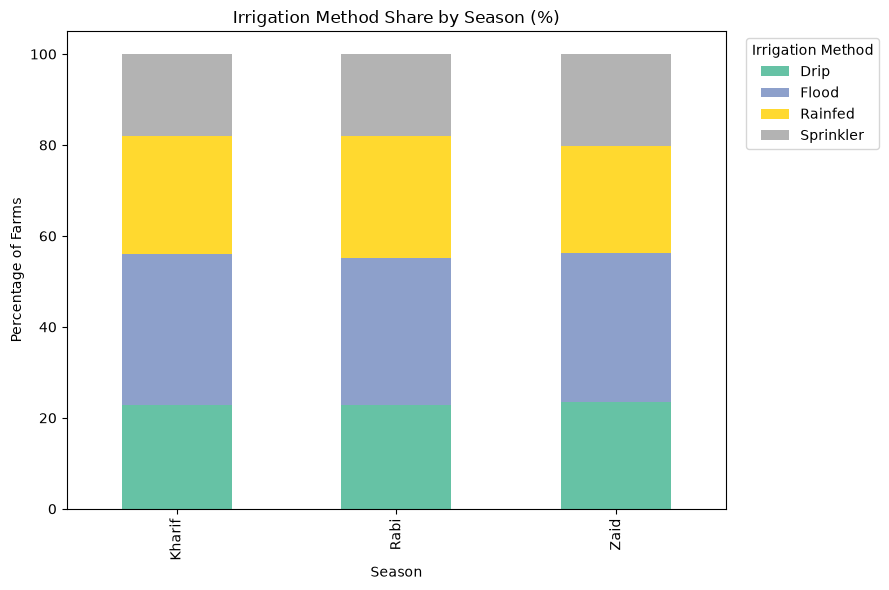

In [67]:
irrigation_season.plot(kind='bar', stacked=True, figsize=(9,6), colormap='Set2')
plt.title('Irrigation Method Share by Season (%)')
plt.ylabel('Percentage of Farms')
plt.legend(title='Irrigation Method', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('irrigation_share_by_season.png', dpi=120)
plt.show()


## Crop-wise Seasonal Performance

In [68]:
crop_season_yield = df.groupby(['Crop','Season'])['Yield_Tonnes_Ha'].mean().unstack().reindex(columns=season_order)
crop_season_yield.round(2)


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.19
Cotton,1.38,1.20,0.96
Groundnut,1.49,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.66
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.28,38.42
Wheat,2.25,2.06,1.75


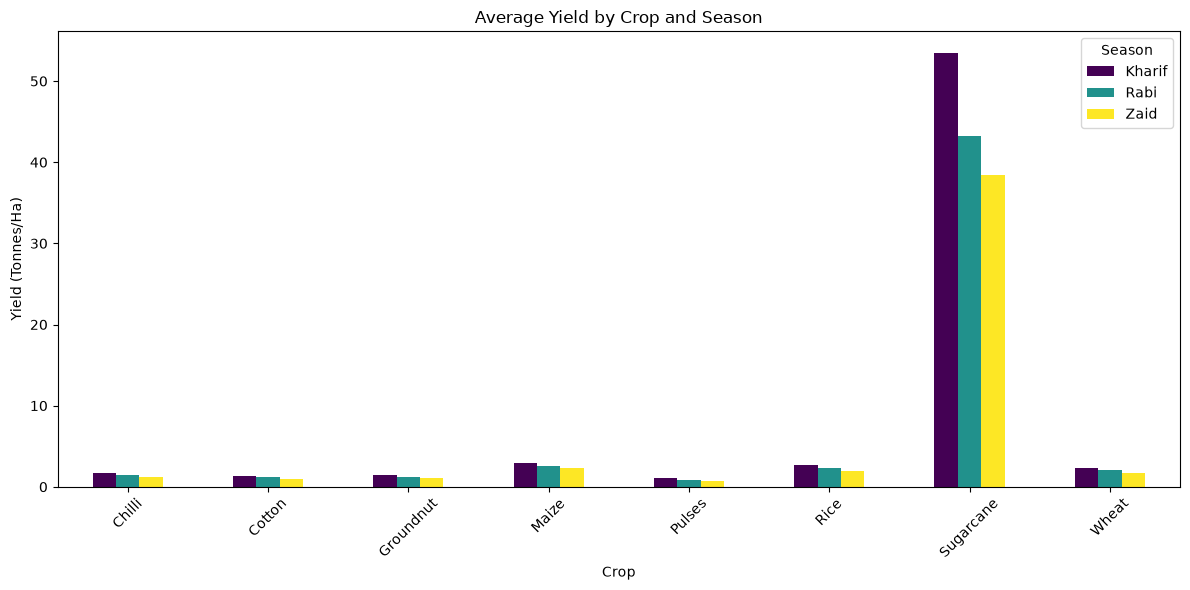

In [69]:
crop_season_yield.plot(kind='bar', figsize=(12,6), colormap='viridis')
plt.title('Average Yield by Crop and Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.legend(title='Season')
plt.tight_layout()
plt.savefig('crop_season_yield.png', dpi=120)
plt.show()


## State-wise Seasonal Profitability

In [70]:
state_season_profit = df.groupby(['State','Season'])['Profit_INR'].mean().unstack().reindex(columns=season_order)
state_season_profit.round(0)


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169316.0,26316.0,-84085.0
Gujarat,217051.0,82846.0,-106930.0
Karnataka,201226.0,70953.0,23311.0
Madhya Pradesh,134242.0,61576.0,210.0
Maharashtra,168801.0,159582.0,-40598.0
Punjab,133779.0,169295.0,62110.0
Tamil Nadu,211304.0,70457.0,-15175.0
Telangana,199668.0,62825.0,-34621.0


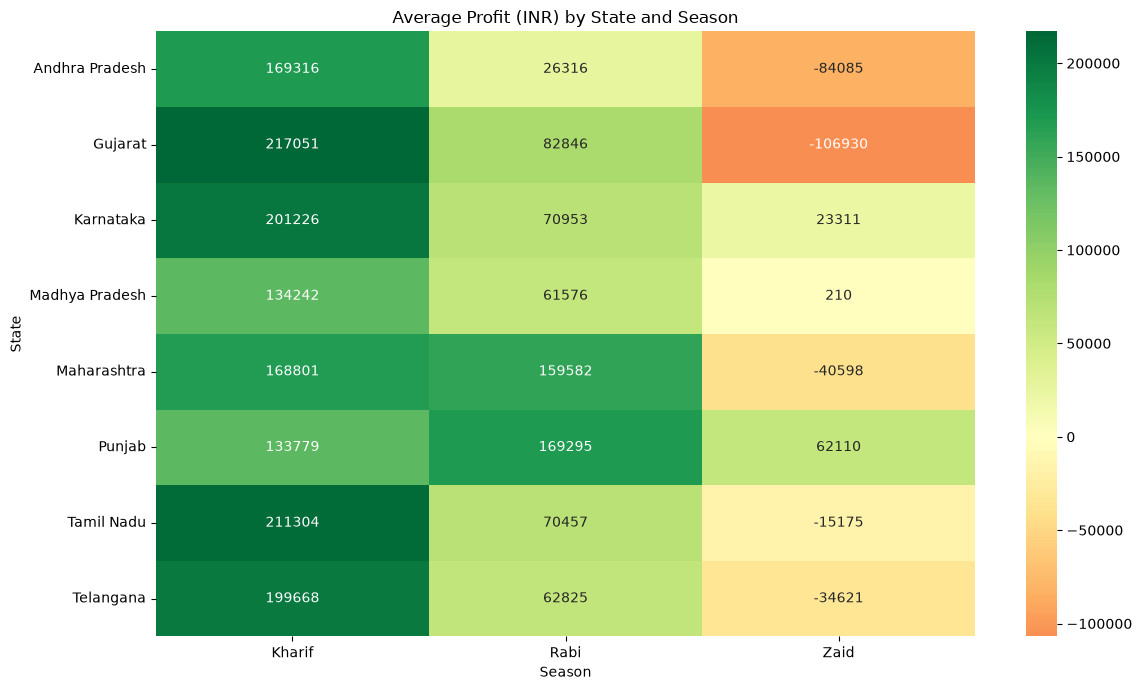

In [71]:
fig, ax = plt.subplots(figsize=(12,7))
sns.heatmap(state_season_profit, annot=True, fmt='.0f', cmap='RdYlGn', center=0, ax=ax)
ax.set_title('Average Profit (INR) by State and Season')
plt.tight_layout()
plt.savefig('state_season_profit_heatmap.png', dpi=120)
plt.show()


## Correlation Analysis

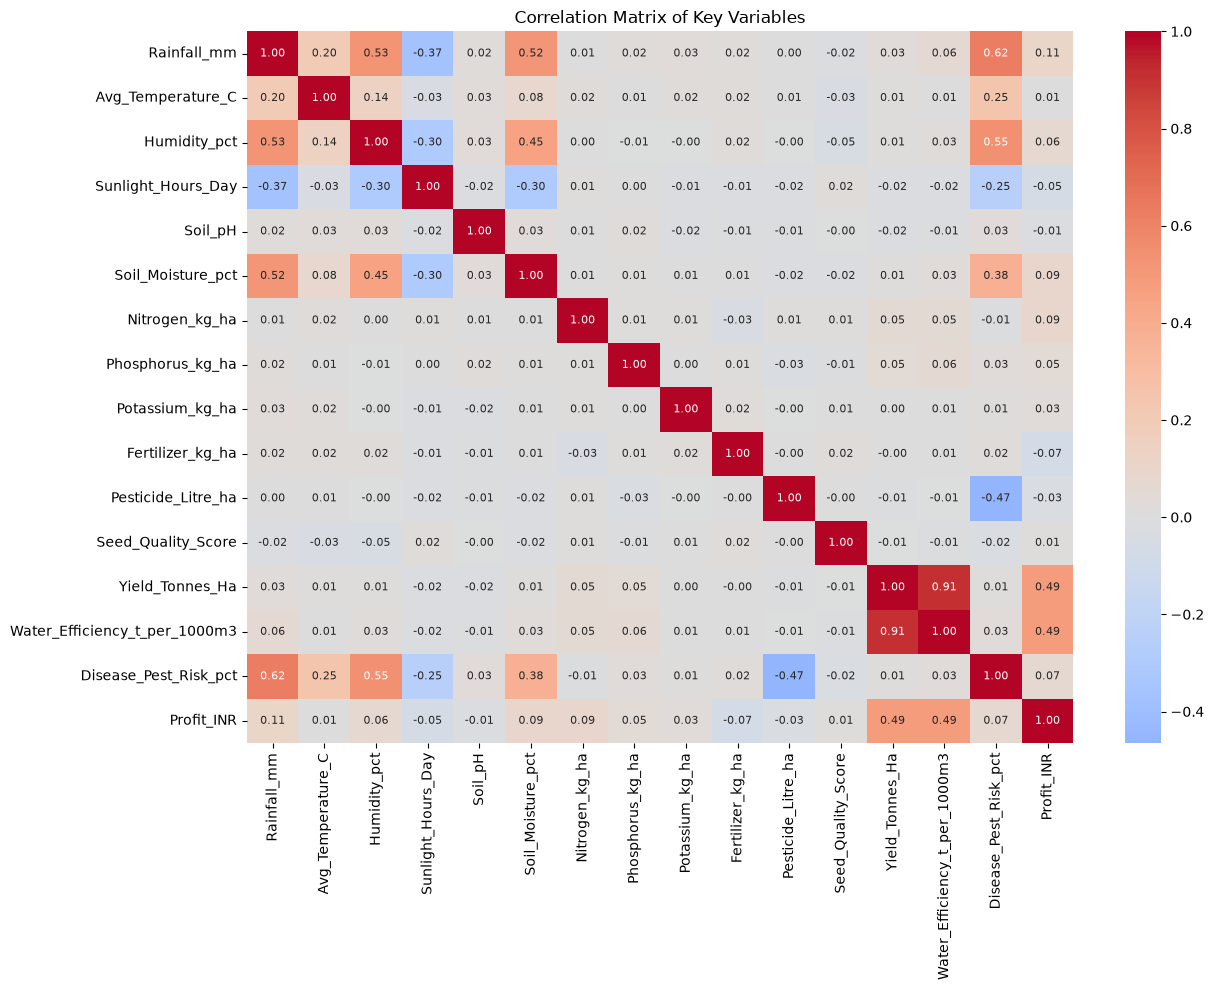

In [72]:
numeric_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day',
                'Soil_pH','Soil_Moisture_pct','Nitrogen_kg_ha','Phosphorus_kg_ha','Potassium_kg_ha',
                'Fertilizer_kg_ha','Pesticide_Litre_ha','Seed_Quality_Score',
                'Yield_Tonnes_Ha','Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct','Profit_INR']

corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(13,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, annot_kws={"size":8})
plt.title('Correlation Matrix of Key Variables')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=120)
plt.show()


In [74]:
print("Correlation of variables with Yield_Tonnes_Ha:")
print(corr['Yield_Tonnes_Ha'].sort_values(ascending=False))
print()
print("Correlation of variables with Profit_INR:")
print(corr['Profit_INR'].sort_values(ascending=False))


Correlation of variables with Yield_Tonnes_Ha:
Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.912561
Profit_INR                       0.488459
Nitrogen_kg_ha                   0.053167
Phosphorus_kg_ha                 0.047974
Rainfall_mm                      0.028836
Disease_Pest_Risk_pct            0.014351
Humidity_pct                     0.012337
Soil_Moisture_pct                0.011101
Avg_Temperature_C                0.010026
Potassium_kg_ha                  0.003363
Fertilizer_kg_ha                -0.000003
Seed_Quality_Score              -0.007231
Pesticide_Litre_ha              -0.007789
Sunlight_Hours_Day              -0.015362
Soil_pH                         -0.020691
Name: Yield_Tonnes_Ha, dtype: float64

Correlation of variables with Profit_INR:
Profit_INR                       1.000000
Water_Efficiency_t_per_1000m3    0.489487
Yield_Tonnes_Ha                  0.488459
Rainfall_mm                      0.106117
Soil_Moisture_pct               

## Statistical Significance Testing

In [75]:
# One-way ANOVA: Is the difference in Yield across seasons statistically significant?
kharif_yield = df[df['Season']=='Kharif']['Yield_Tonnes_Ha']
rabi_yield = df[df['Season']=='Rabi']['Yield_Tonnes_Ha']
zaid_yield = df[df['Season']=='Zaid']['Yield_Tonnes_Ha']

f_stat, p_value = stats.f_oneway(kharif_yield, rabi_yield, zaid_yield)
print(f"ANOVA for Yield across Seasons: F-statistic = {f_stat:.2f}, p-value = {p_value:.5f}")

f_stat2, p_value2 = stats.f_oneway(
    df[df['Season']=='Kharif']['Profit_INR'],
    df[df['Season']=='Rabi']['Profit_INR'],
    df[df['Season']=='Zaid']['Profit_INR']
)
print(f"ANOVA for Profit across Seasons: F-statistic = {f_stat2:.2f}, p-value = {p_value2:.5f}")


ANOVA for Yield across Seasons: F-statistic = 1.55, p-value = 0.21156
ANOVA for Profit across Seasons: F-statistic = 34.29, p-value = 0.00000
